# Semana 12: Aprendizaje Supervisado (Clasificación)

Usamos los grupos que creó el K-Means (Semana 10) como etiqueta, y entrenamos modelos supervisados que aprendan a predecir a qué grupo pertenece cada alojamiento, a partir de sus características (precio, puntuación y tipo).

La idea de negocio: clasificar automáticamente un alojamiento en su segmento de mercado. Controlamos la profundidad del árbol para que el modelo aprenda el patrón general en vez de memorizar los datos, buscando una precisión realista (no del 100%).

## Cargar los datos con la etiqueta del cluster

In [1]:
import os
from dotenv import load_dotenv
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

spark = SparkSession.builder \
    .appName("Supervisado_Alojamientos") \
    .config("spark.mongodb.read.connection.uri", MONGO_URI) \
    .config("spark.mongodb.write.connection.uri", MONGO_URI) \
    .getOrCreate()

df = spark.read.format("mongodb") \
    .option("database", "proyecto_bigdata") \
    .option("collection", "datos_clusters") \
    .load()

print("Registros cargados:", df.count())
df.select("nombre_hotel", "precio_clp", "puntuacion", "tipo_alojamiento", "prediction").show(10)

Registros cargados: 3584
+--------------------+----------+----------+----------------+----------+
|        nombre_hotel|precio_clp|puntuacion|tipo_alojamiento|prediction|
+--------------------+----------+----------+----------------+----------+
|Apart Hotel Andin...|   82822.0|       7.0|     apartamento|         1|
|Apart Hotel Andin...|   79329.0|       7.1|     apartamento|         1|
|  Apart Hotel Astore|  158700.0|       7.1|     apartamento|         2|
|Apart Hotel Centr...|   80781.0|       9.5|     apartamento|         0|
|Apart Hotel Centr...|  118247.0|       7.3|     apartamento|         1|
|Apart Hotel Costa...|   63625.0|       9.6|     apartamento|         0|
|Apart Hotel Costa...|   97591.0|       7.5|     apartamento|         1|
|Apart Hotel Del M...|   78879.0|       7.3|     apartamento|         1|
|Apart Hotel Del M...|  106047.0|       7.4|     apartamento|         1|
|Apart Hotel Norte...|   96889.0|       8.7|     apartamento|         0|
+--------------------+----

## Preparar los datos

Recreamos el vector de características (precio y puntuación, las mismas que usó el K-Means) y lo escalamos. Renombramos la columna del cluster (`prediction`) a `label`, que es el nombre que esperan los modelos supervisados de Spark.

In [2]:
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler

df_clas = df.dropna(subset=["precio_clp", "puntuacion", "tipo_alojamiento", "prediction"])

# Tipo a numero
indexer = StringIndexer(inputCol="tipo_alojamiento", outputCol="tipo_idx")
df_clas = indexer.fit(df_clas).transform(df_clas)

# Vector con precio, puntuacion y tipo
assembler = VectorAssembler(inputCols=["precio_clp", "puntuacion", "tipo_idx"], outputCol="features")
df_vector = assembler.transform(df_clas)

scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
df_scaled = scaler.fit(df_vector).transform(df_vector)

df_supervisado = df_scaled.withColumnRenamed("prediction", "label")
print("Datos preparados. Predecimos el grupo con precio, puntuacion y tipo.")
print("Registros:", df_supervisado.count())

Datos preparados. Predecimos el grupo con precio, puntuacion y tipo.
Registros: 3584


## Dividir en entrenamiento y prueba
70% para que el modelo aprenda, 30% para probarlo con datos que no vio.

In [3]:
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)
print("Entrenamiento:", train_data.count())
print("Prueba:", test_data.count())

Entrenamiento: 2568
Prueba: 1016


## Modelo 1: Árbol de Decisión

El árbol de decisión es ideal porque es visual y deja ver las "reglas" que el K-Means usó para agrupar (por ejemplo: si el precio es mayor a X, va al grupo premium).

In [4]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# maxDepth=3 controla el arbol: aprende el patron general, no memoriza.
# Esto baja el accuracy a un rango realista en vez de llegar al 100%.
dt = DecisionTreeClassifier(featuresCol="scaledFeatures", labelCol="label", maxDepth=3, seed=42)
dt_model = dt.fit(train_data)
pred_dt = dt_model.transform(test_data)

print("=== Predicciones del Árbol de Decisión ===")
pred_dt.select("nombre_hotel", "label", "prediction").show(10)

=== Predicciones del Árbol de Decisión ===
+--------------------+-----+----------+
|        nombre_hotel|label|prediction|
+--------------------+-----+----------+
|  Apart Hotel Astore|    2|       2.0|
|Apart Hotel Costa...|    1|       1.0|
|Apart Hotel Del M...|    1|       1.0|
|Apart Hotel Norte...|    0|       0.0|
|Apart Hotel Prima...|    0|       2.0|
|Apart Hotel Sur A...|    0|       0.0|
|Apart Hotel Sur A...|    1|       1.0|
|Hotel Antofagasta...|    1|       1.0|
|Hotel Florencia S...|    2|       2.0|
|    ibis Antofagasta|    1|       1.0|
+--------------------+-----+----------+
only showing top 10 rows



In [5]:
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
acc_dt = evaluator.evaluate(pred_dt)
print(f"Precisión del Árbol de Decisión (Accuracy): {acc_dt*100:.2f}%")

Precisión del Árbol de Decisión (Accuracy): 95.18%


### Reglas que aprendió el árbol
Vemos la estructura lógica del árbol: las reglas que usa para decidir a qué grupo va cada alojamiento.

In [6]:
print("=== ESTRUCTURA LÓGICA DEL ÁRBOL ===")
print(dt_model.toDebugString)

=== ESTRUCTURA LÓGICA DEL ÁRBOL ===
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_6158d144e370, depth=2, numNodes=7, numClasses=3, numFeatures=3
  If (feature 1 <= 10.167313425523844)
   If (feature 0 <= 2.6076718064959805)
    Predict: 1.0
   Else (feature 0 > 2.6076718064959805)
    Predict: 2.0
  Else (feature 1 > 10.167313425523844)
   If (feature 0 <= 2.3940000104807364)
    Predict: 0.0
   Else (feature 0 > 2.3940000104807364)
    Predict: 2.0



### Graficar el árbol de decisión

Spark no puede dibujar el árbol directamente (su graficador está en otra librería). El truco, igual que en el material del curso, es entrenar rápidamente un árbol equivalente con scikit-learn usando los mismos datos, solo para poder dibujarlo con ramas y colores.

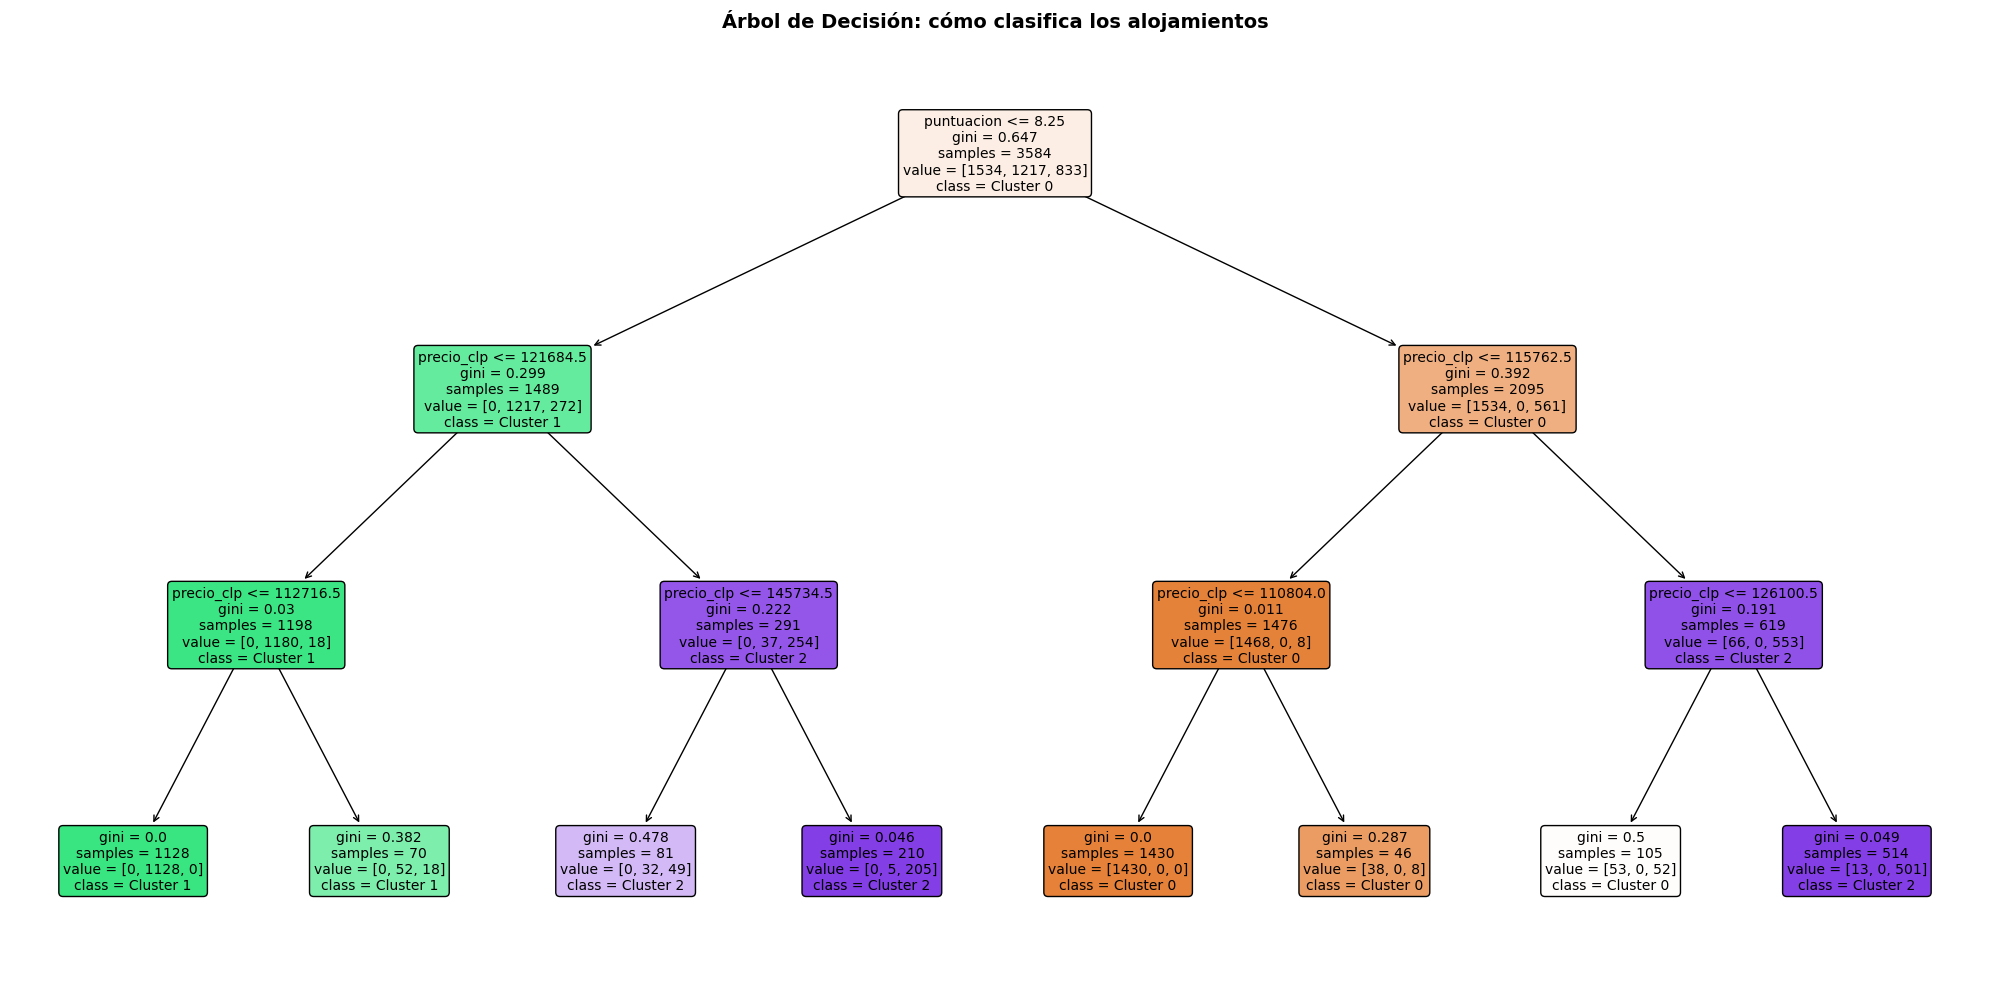

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier

# Pasamos los datos a pandas para scikit-learn
df_pandas = df_supervisado.select("precio_clp", "puntuacion", "tipo_idx", "label").toPandas()

X_muestra = df_pandas[["precio_clp", "puntuacion", "tipo_idx"]]
y_muestra = df_pandas["label"]

# Entrenamos un arbol de scikit-learn (mismo maxDepth=3) solo para graficar
sk_dt = SklearnClassifier(max_depth=3, random_state=42)
sk_dt.fit(X_muestra, y_muestra)

plt.figure(figsize=(20,10))
plot_tree(sk_dt,
          feature_names=["precio_clp", "puntuacion", "tipo"],
          class_names=["Cluster 0", "Cluster 1", "Cluster 2"],
          filled=True, rounded=True, fontsize=10)
plt.title("Árbol de Decisión: cómo clasifica los alojamientos", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## Modelo 2 y 3: Random Forest y comparación

Probamos también un Random Forest (varios árboles juntos) para comparar. Así vemos cuál modelo replica mejor los grupos del K-Means.

In [8]:
from pyspark.ml.classification import RandomForestClassifier

# Random Forest tambien controlado (maxDepth=3) para comparar de forma justa
rf = RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label",
                            numTrees=20, maxDepth=3, seed=42)
rf_model = rf.fit(train_data)
pred_rf = rf_model.transform(test_data)
acc_rf = evaluator.evaluate(pred_rf)

print("="*45)
print(f"{'Modelo':<25}{'Accuracy':>15}")
print("="*45)
print(f"{'Árbol de Decisión':<25}{acc_dt*100:>13.2f}%")
print(f"{'Random Forest':<25}{acc_rf*100:>13.2f}%")
print("="*45)

Modelo                          Accuracy
Árbol de Decisión                95.18%
Random Forest                    96.26%


## Matriz de confusión

La matriz muestra cuántos alojamientos clasificó bien y cuántos confundió, grupo por grupo. La diagonal son los aciertos.

In [9]:
import pandas as pd

pdf_conf = pred_dt.select("label", "prediction").toPandas()
matriz = pd.crosstab(pdf_conf["label"], pdf_conf["prediction"],
                     rownames=["Real"], colnames=["Predicho"])
print("=== MATRIZ DE CONFUSIÓN (Árbol de Decisión) ===")
print(matriz)

=== MATRIZ DE CONFUSIÓN (Árbol de Decisión) ===
Predicho  0.0  1.0  2.0
Real                   
0         403    0    9
1           0  334    7
2          17   16  230


## Conclusiones

(Completar según los resultados: qué accuracy se obtuvo, qué modelo fue mejor, y qué significa. Un accuracy alto es esperable aquí, porque el modelo supervisado aprende a replicar los grupos que el K-Means ya definió usando las mismas variables. Esto confirma que los grupos son consistentes y que un modelo puede clasificar alojamientos nuevos automáticamente en su segmento.)